In [1]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.hyperparameter_search.random_search import OptimalXGBHyperparameterSearch

In [2]:
RANDOM_SEED = 32
# SELECTION_METRIC must match rfe.ipynb; it maps to the sklearn scoring name used for
# hyperparameter tuning so tuning optimizes the same objective as feature selection.
# BEST_NUM_FEATS (from rfe.ipynb's 1-SE output) and SELECTED_RFE_CSV are set per run.
SELECTION_METRIC = 'brier'
_SCORING = {'brier': 'neg_brier_score', 'roc_auc': 'roc_auc', 'log_loss': 'neg_log_loss'}[SELECTION_METRIC]
BEST_NUM_FEATS = 55
SELECTED_RFE_CSV = 'rfe_features_kfolds_full_brier.csv'
TARGET = 'target_win'

RANDOM_XGB_PARAMS = {
    'learning_rate': [.03, .05, .1, .15, .2],
    'max_depth': [2, 3],
    'subsample': [.5, .7, .9],
    'min_child_weight': [10, 20, 50, 100],
    'gamma': [.5, 1, 5, 10, 100],
    'n_estimators': [10, 20,30, 40, 50],
    'early_stopping_rounds': [10, 20, 50],
    'importance_type': ['total_gain'],
    'eval_metric': ['auc']
}

RANDOM_SEARCH_PARAMS = dict(
    n_iter=100,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scoring=_SCORING,
)

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    f'../../../../../data/predict_games/model_features_in/{SELECTED_RFE_CSV}',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

MODEL_INPUTS_DF = MODEL_INPUTS_DF.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

np.random.seed(RANDOM_SEED)

In [3]:
# Two-season holdout: train on everything before 2022, use 2022-2023 as the early-stopping
# test slice, and hold out 2024+2025 (the original 3-way split shifted one year forward).
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2022)]
test_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2022) & (MODEL_INPUTS_DF['season'] < 2024)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] >= 2024].copy()
X_train = train_df[BEST_FEATS_FROM_RFE]
y_train = train_df[TARGET]
X_test = test_df[BEST_FEATS_FROM_RFE]
y_test = test_df[TARGET]
X_holdout = holdout_df[BEST_FEATS_FROM_RFE]
y_holdout = holdout_df[TARGET]

In [4]:
rand_hyperparam_search = OptimalXGBHyperparameterSearch(
    X_train, y_train, X_test, y_test
)

In [5]:
rand_search = rand_hyperparam_search.search(
    RANDOM_XGB_PARAMS, **RANDOM_SEARCH_PARAMS
)

[0]	validation_0-auc:0.63197	validation_1-auc:0.61080
[1]	validation_0-auc:0.65845	validation_1-auc:0.63098
[2]	validation_0-auc:0.67292	validation_1-auc:0.63978
[3]	validation_0-auc:0.67946	validation_1-auc:0.64764
[4]	validation_0-auc:0.68501	validation_1-auc:0.65192
[0]	validation_0-auc:0.61790	validation_1-auc:0.59212
[5]	validation_0-auc:0.69310	validation_1-auc:0.65741
[1]	validation_0-auc:0.62904	validation_1-auc:0.59802
[6]	validation_0-auc:0.69824	validation_1-auc:0.66030
[7]	validation_0-auc:0.70091	validation_1-auc:0.66432
[2]	validation_0-auc:0.64575	validation_1-auc:0.61638
[8]	validation_0-auc:0.70348	validation_1-auc:0.66325
[3]	validation_0-auc:0.64810	validation_1-auc:0.61303
[0]	validation_0-auc:0.64049	validation_1-auc:0.62403
[9]	validation_0-auc:0.70523	validation_1-auc:0.66355
[0]	validation_0-auc:0.63772	validation_1-auc:0.63128
[1]	validation_0-auc:0.66744	validation_1-auc:0.64061
[4]	validation_0-auc:0.65662	validation_1-auc:0.62314
[10]	validation_0-auc:0.7066

[7]	validation_0-auc:0.66565	validation_1-auc:0.63970
[36]	validation_0-auc:0.69896	validation_1-auc:0.65148
[28]	validation_0-auc:0.72078	validation_1-auc:0.65389
[30]	validation_0-auc:0.69062	validation_1-auc:0.65706
[30]	validation_0-auc:0.69556	validation_1-auc:0.65661
[25]	validation_0-auc:0.73104	validation_1-auc:0.65354
[6]	validation_0-auc:0.70131	validation_1-auc:0.65312
[13]	validation_0-auc:0.71957	validation_1-auc:0.66324
[25]	validation_0-auc:0.72249	validation_1-auc:0.66050
[8]	validation_0-auc:0.66706	validation_1-auc:0.64018
[37]	validation_0-auc:0.69966	validation_1-auc:0.65133
[31]	validation_0-auc:0.69122	validation_1-auc:0.65752
[36]	validation_0-auc:0.72881	validation_1-auc:0.65512
[25]	validation_0-auc:0.72193	validation_1-auc:0.65167
[15]	validation_0-auc:0.71387	validation_1-auc:0.65932
[31]	validation_0-auc:0.69634	validation_1-auc:0.65720
[29]	validation_0-auc:0.72068	validation_1-auc:0.65434
[28]	validation_0-auc:0.69252	validation_1-auc:0.66488
[7]	validatio

[7]	validation_0-auc:0.69595	validation_1-auc:0.65142
[1]	validation_0-auc:0.66251	validation_1-auc:0.63584
[14]	validation_0-auc:0.70779	validation_1-auc:0.66352
[14]	validation_0-auc:0.71650	validation_1-auc:0.66412
[5]	validation_0-auc:0.68727	validation_1-auc:0.64956
[48]	validation_0-auc:0.70295	validation_1-auc:0.65995
[0]	validation_0-auc:0.61437	validation_1-auc:0.59630
[0]	validation_0-auc:0.61397	validation_1-auc:0.58527
[8]	validation_0-auc:0.69630	validation_1-auc:0.64916
[15]	validation_0-auc:0.70783	validation_1-auc:0.66223
[2]	validation_0-auc:0.67183	validation_1-auc:0.64787
[6]	validation_0-auc:0.69147	validation_1-auc:0.65581
[4]	validation_0-auc:0.68228	validation_1-auc:0.64782
[49]	validation_0-auc:0.70337	validation_1-auc:0.66051
[1]	validation_0-auc:0.63092	validation_1-auc:0.61537
[1]	validation_0-auc:0.63162	validation_1-auc:0.59889
[9]	validation_0-auc:0.69954	validation_1-auc:0.65143
[16]	validation_0-auc:0.70909	validation_1-auc:0.66214
[7]	validation_0-auc:0

[42]	validation_0-auc:0.70840	validation_1-auc:0.66246
[39]	validation_0-auc:0.70527	validation_1-auc:0.66098
[41]	validation_0-auc:0.70888	validation_1-auc:0.65835
[37]	validation_0-auc:0.70377	validation_1-auc:0.66302
[32]	validation_0-auc:0.70236	validation_1-auc:0.67123
[43]	validation_0-auc:0.70833	validation_1-auc:0.66201
[40]	validation_0-auc:0.70563	validation_1-auc:0.66073
[42]	validation_0-auc:0.70880	validation_1-auc:0.65847
[38]	validation_0-auc:0.70454	validation_1-auc:0.66354
[44]	validation_0-auc:0.70866	validation_1-auc:0.66186
[33]	validation_0-auc:0.70311	validation_1-auc:0.67134
[41]	validation_0-auc:0.70602	validation_1-auc:0.66169
[43]	validation_0-auc:0.70941	validation_1-auc:0.65803
[45]	validation_0-auc:0.70939	validation_1-auc:0.66243
[44]	validation_0-auc:0.70951	validation_1-auc:0.65783
[34]	validation_0-auc:0.70392	validation_1-auc:0.67165
[42]	validation_0-auc:0.70623	validation_1-auc:0.66183
[0]	validation_0-auc:0.63943	validation_1-auc:0.62082
[39]	valida

[12]	validation_0-auc:0.63713	validation_1-auc:0.61107
[2]	validation_0-auc:0.60628	validation_1-auc:0.59129
[19]	validation_0-auc:0.70300	validation_1-auc:0.65760
[14]	validation_0-auc:0.64057	validation_1-auc:0.62756
[13]	validation_0-auc:0.63631	validation_1-auc:0.61039
[9]	validation_0-auc:0.62062	validation_1-auc:0.60127
[0]	validation_0-auc:0.57363	validation_1-auc:0.57274
[3]	validation_0-auc:0.63798	validation_1-auc:0.61802
[15]	validation_0-auc:0.64033	validation_1-auc:0.62901
[14]	validation_0-auc:0.63631	validation_1-auc:0.61039
[10]	validation_0-auc:0.62062	validation_1-auc:0.60127
[4]	validation_0-auc:0.63798	validation_1-auc:0.61802
[1]	validation_0-auc:0.61310	validation_1-auc:0.60725
[16]	validation_0-auc:0.63986	validation_1-auc:0.63017
[15]	validation_0-auc:0.63631	validation_1-auc:0.61039
[11]	validation_0-auc:0.62062	validation_1-auc:0.60127
[5]	validation_0-auc:0.63614	validation_1-auc:0.62121
[2]	validation_0-auc:0.61745	validation_1-auc:0.60661
[17]	validation_0-

...

[46]	validation_0-auc:0.71618	validation_1-auc:0.66138


[47]	validation_0-auc:0.71649	validation_1-auc:0.66129


[48]	validation_0-auc:0.71729	validation_1-auc:0.66102


[49]	validation_0-auc:0.71785	validation_1-auc:0.66117




Best parameters found:  {'subsample': 0.5, 'n_estimators': 50, 'min_child_weight': 50, 'max_depth': 2, 'learning_rate': 0.15, 'importance_type': 'total_gain', 'gamma': 0.5, 'eval_metric': 'auc', 'early_stopping_rounds': 50}


Best score found:  -0.22439772156704357


Best Selected Features:  ['is_home_target', 'off_opp_success_rate_competitive_cumulative_average', 'off_target_run_middle_yards_per_attempt_competitive_cumulative_average', 'opp_def_cumulative_avg_points_allowed', 'off_target_run_left_tackle_yards_per_attempt_competitive_cumulative_average', 'def_opp_run_right_end_yards_per_attempt_garbage_trailing_cumulative_average', 'off_opp_run_middle_yards_per_attempt_competitive_cumulative_average', 'def_opp_cpoe_garbage_trailing_cumulative_average', 'off_target_rush_epa_per_carry_garbage_leading_cumulative_average', 'def_target_run_left_guard_yards_per_attempt_competitive_cumulative_average', 'def_opp_seconds_per_play_garbage_leading_cumulative_average', 'def_opp_rushing_first_dow

In [6]:
# view all the scores from the search
rand_search.cv_results_

{'mean_fit_time': array([0.30165892, 0.31671715, 0.28054032, 0.27986383, 0.30941606,
        0.13193927, 0.17268815, 0.13207173, 0.25773969, 0.241646  ,
        0.11886034, 0.11467562, 0.24572077, 0.23803654, 0.28936119,
        0.196737  , 0.15143623, 0.17152438, 0.17247338, 0.10567179,
        0.11078014, 0.17939587, 0.21466889, 0.25697088, 0.24162726,
        0.35743484, 0.16494575, 0.15886502, 0.23846936, 0.23260751,
        0.19897299, 0.32640967, 0.17516937, 0.29147301, 0.11242876,
        0.1182785 , 0.14389458, 0.23205571, 0.11172237, 0.17050409,
        0.26671329, 0.32280598, 0.13076067, 0.15833225, 0.22853417,
        0.12698331, 0.10252128, 0.1502193 , 0.21204357, 0.30468035,
        0.20370364, 0.11776466, 0.31978383, 0.11423593, 0.27217417,
        0.18660741, 0.36730204, 0.14605107, 0.28318601, 0.16113338,
        0.23252554, 0.22129683, 0.1112999 , 0.10666046, 0.17503777,
        0.22247591, 0.14111543, 0.18840733, 0.21500239, 0.31973295,
        0.21724052, 0.16324005,

<Axes: >

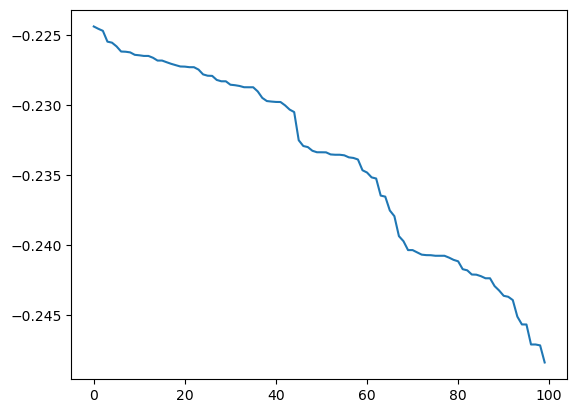

In [7]:
# Graph the search results. Make the index the rank of the score
# another column for the mean test score
rand_search_results = pd.DataFrame(rand_search.cv_results_)
rand_search_results['rank_test_score'] = rand_search_results['rank_test_score']
rand_search_results['mean_test_score'] = rand_search_results['mean_test_score']
rand_search_results = rand_search_results.sort_values(by='rank_test_score', ascending=True)
rand_search_results = rand_search_results.reset_index(drop=True)
rand_search_results['mean_test_score'].plot()

In [8]:
# What are the grid search params for the top 5 scores?
rand_search_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_importance_type,...,param_early_stopping_rounds,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.319784,0.016810,0.004558,0.002777,0.5,50,50,2,0.15,total_gain,...,50,"{'subsample': 0.5, 'n_estimators': 50, 'min_ch...",-0.226486,-0.225879,-0.225437,-0.225216,-0.218971,-0.224398,0.002748,1
1,0.151638,0.008637,0.002427,0.000101,0.5,20,50,3,0.2,total_gain,...,10,"{'subsample': 0.5, 'n_estimators': 20, 'min_ch...",-0.225001,-0.226146,-0.226161,-0.224721,-0.220789,-0.224564,0.001976,2
2,0.298098,0.032523,0.003209,0.000746,0.5,40,20,3,0.2,total_gain,...,50,"{'subsample': 0.5, 'n_estimators': 40, 'min_ch...",-0.224097,-0.225170,-0.226861,-0.223844,-0.223566,-0.224708,0.001206,3
3,0.250199,0.020514,0.002328,0.000088,0.5,50,10,2,0.2,total_gain,...,20,"{'subsample': 0.5, 'n_estimators': 50, 'min_ch...",-0.224769,-0.225810,-0.228777,-0.224864,-0.223171,-0.225478,0.001855,4
4,0.170504,0.012666,0.002938,0.001206,0.5,20,10,2,0.2,total_gain,...,20,"{'subsample': 0.5, 'n_estimators': 20, 'min_ch...",-0.225135,-0.225810,-0.228777,-0.224864,-0.223171,-0.225551,0.001832,5


In [9]:
# save the json of the best model
best_model = rand_search.best_estimator_
best_model.save_model(
    os.path.join(module_path, 'models', 'best_random_xgb_model.json')
)

In [10]:
# What is the score on the holdout set?
best_model.score(X_holdout, y_holdout)

0.6488970588235294

In [11]:
holdout_df.loc[:, 'preds'] = best_model.predict_proba(X_holdout)[:, 1]

In [12]:
# Single overall hold-out AUROC, computed exactly like bart.ipynb, reported alongside
# Brier/log-loss so every run is comparable on all axes regardless of selection metric.
overall_holdout_auroc = roc_auc_score(holdout_df['target_win'], holdout_df['preds'])
print(f'2024+2025 hold-out ROC-AUC (overall): {overall_holdout_auroc:.4f}  '
      f'[{BEST_NUM_FEATS} features, {SELECTED_RFE_CSV}, selected on {SELECTION_METRIC}]')

2024+2025 hold-out ROC-AUC (overall): 0.6978  [55 features, rfe_features_kfolds_full_brier.csv, selected on brier]


In [13]:
# Show the predictions for the holdout set
results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds
0,2024_01_ARI_BUF,1,ARI,BUF,0,0.198208
1,2024_01_ARI_BUF,1,BUF,ARI,1,0.836088
2,2024_01_BAL_KC,1,KC,BAL,1,0.430004
3,2024_01_BAL_KC,1,BAL,KC,0,0.527949
4,2024_01_CAR_NO,1,CAR,NO,0,0.194926
...,...,...,...,...,...,...
1083,2025_18_SEA_SF,18,SF,SEA,0,0.584317
1084,2025_18_TEN_JAX,18,JAX,TEN,1,0.760890
1085,2025_18_TEN_JAX,18,TEN,JAX,0,0.200957
1086,2025_18_WAS_PHI,18,PHI,WAS,0,0.718254


week
1     0.833984
2     0.667969
3     0.503906
4     0.674805
5     0.522959
6     0.699168
7     0.804444
8     0.753864
9     0.755054
10    0.678571
11    0.736029
12    0.761317
13    0.722656
14    0.790123
15    0.773438
16    0.655273
17    0.666992
18    0.629883
dtype: float64

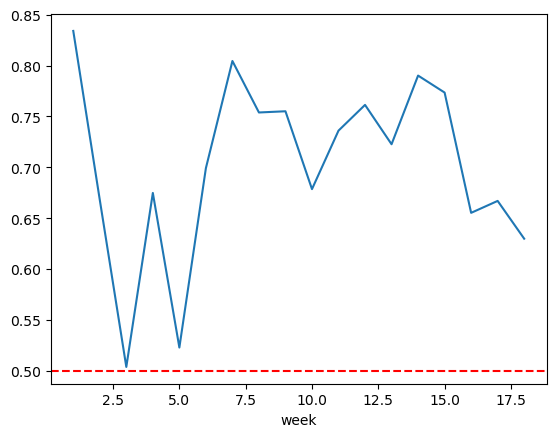

In [14]:
# get the AUROC score by week
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

In [15]:
# for each game_id, only keep the higher prediction
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)

week
1     0.806763
2     0.541126
3     0.503906
4     0.789683
5     0.520408
6     0.631579
7     0.724868
8     0.630952
9     0.721053
10    0.605556
11    0.694737
12    0.492857
13    0.732794
14    0.703947
15    0.546875
16    0.760784
17    0.519481
18    0.619048
dtype: float64

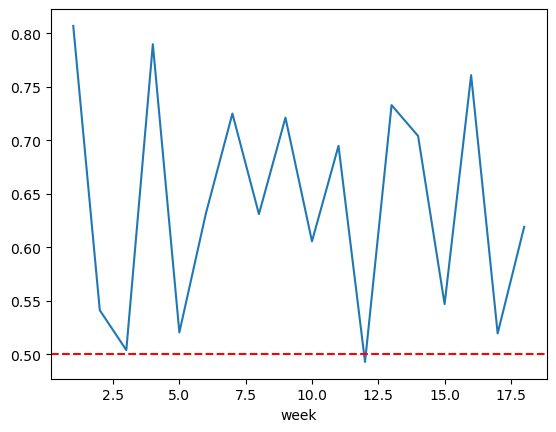

In [16]:
# get the AUROC score by week
weekly_scores = higher_preds.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

## How good are the model's *confident* predictions?

AUROC only measures **ranking** (can the model sort winners above losers?). It says
nothing about whether a 0.80 prediction is actually right ~80% of the time. The cells
below answer "when the model has a strong prediction, how well does it predict?" using:

1. **Brier score & log loss** — residual-based metrics that penalize overconfidence.
2. **Confidence-bucketed accuracy** — the direct answer: how often the favored team wins,
   grouped by how sure the model was.
3. **Reliability diagram** — visual calibration check (predicted prob vs observed win rate).

Note: `holdout_df` has two rows per `game_id` (one per team). Brier/log loss are computed
on all rows consistently; the bucketed-accuracy table uses the one-row-per-game `higher_preds`
frame so each game is counted once.

In [17]:
# Residual-based metrics. Unlike AUROC, these penalize confident-and-wrong predictions.
from sklearn.metrics import brier_score_loss, log_loss

brier = brier_score_loss(holdout_df['target_win'], holdout_df['preds'])
ll = log_loss(holdout_df['target_win'], holdout_df['preds'])
print(f"Brier score: {brier:.4f}  (lower is better; 0.25 = coin flip)")
print(f"Log loss:    {ll:.4f}  (lower is better; punishes confident-and-wrong hardest)")

Brier score: 0.2205  (lower is better; 0.25 = coin flip)
Log loss:    0.6309  (lower is better; punishes confident-and-wrong hardest)


In [18]:
# Confidence-bucketed accuracy: the direct answer to "when the model is confident, is it right?"
# On higher_preds, `preds` is the model's confidence in its pick (0.5-1.0) and
# target_win == 1 means the favored team actually won.
higher_preds['confidence'] = higher_preds['preds']
higher_preds['bucket'] = pd.cut(
    higher_preds['confidence'], bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

confidence_summary = higher_preds.groupby('bucket', observed=True).agg(
    n_games=('target_win', 'size'),
    pick_accuracy=('target_win', 'mean'),   # how often the favored team won
    avg_confidence=('confidence', 'mean'),  # what the model claimed
)
# Positive gap = overconfident (claimed more than it delivered)
confidence_summary['calibration_gap'] = (
    confidence_summary['avg_confidence'] - confidence_summary['pick_accuracy']
)
confidence_summary

,n_games,pick_accuracy,avg_confidence,calibration_gap
bucket,,,,
"(0.5, 0.6]",209,0.564593,0.553925,-0.010668
"(0.6, 0.7]",172,0.674419,0.646592,-0.027827
"(0.7, 0.8]",117,0.752137,0.743990,-0.008146
"(0.8, 0.9]",16,0.937500,0.820052,-0.117448


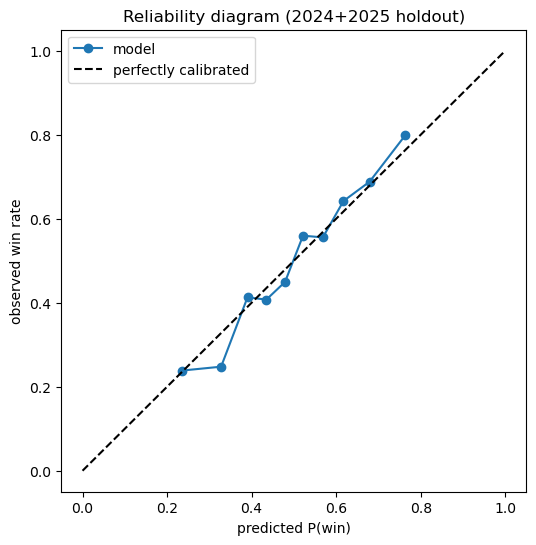

In [19]:
# Reliability diagram: are the probabilities trustworthy?
# Points on the diagonal = perfectly calibrated. Below the diagonal on the right
# side = the model is overconfident when bullish.
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    holdout_df['target_win'], holdout_df['preds'], n_bins=10, strategy='quantile'
)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='model')
plt.plot([0, 1], [0, 1], 'k--', label='perfectly calibrated')
plt.xlabel('predicted P(win)')
plt.ylabel('observed win rate')
plt.title('Reliability diagram (2024+2025 holdout)')
plt.legend()
plt.show()

## Does a wider home-vs-away gap mean better predictions?

Each game has two predictions: `P(home wins)` from the home-perspective row and
`P(away wins)` from the away-perspective row. The **gap** between them is a stronger
confidence signal than `max(pred)` alone — it uses *both* perspectives. A wide gap
means the two views agree strongly on a winner; a narrow gap means the model is torn.

Hypothesis: when the gap is wide, accuracy should be higher. We pivot the two rows onto
one row per game (via `is_home_target`), define the model's pick as whichever side has
the higher probability, and bucket accuracy by gap width (quintiles, so every bin is
populated).

In [20]:
# Pivot the two perspectives of each game onto one row (is_home_target: 1 = home, 0 = away)
game_view = holdout_df.pivot_table(
    index='game_id', columns='is_home_target', values=['preds', 'target_win'], aggfunc='first'
).dropna()

games = pd.DataFrame({
    'home_pred': game_view[('preds', 1)],
    'away_pred': game_view[('preds', 0)],
    'home_won':  game_view[('target_win', 1)].astype(int),
})
games['gap']           = games['home_pred'] - games['away_pred']   # >0 leans home, <0 leans away
games['abs_gap']       = games['gap'].abs()                        # strength of the lean
games['pred_home_win'] = games['home_pred'] > games['away_pred']
games['correct']       = games['pred_home_win'] == (games['home_won'] == 1)

# Bucket by gap width (quintiles) and measure accuracy in each
games['gap_quintile'] = pd.qcut(games['abs_gap'], 5)
gap_summary = games.groupby('gap_quintile', observed=True).agg(
    n_games=('correct', 'size'),
    mean_abs_gap=('abs_gap', 'mean'),
    accuracy=('correct', 'mean'),
)
print(f"Overall correlation(abs_gap, correct): {games['abs_gap'].corr(games['correct'].astype(int)):.3f}")
gap_summary

Overall correlation(abs_gap, correct): 0.227


,n_games,mean_abs_gap,accuracy
gap_quintile,,,
"(-0.000754, 0.089]",109,0.041338,0.486239
"(0.089, 0.176]",109,0.129835,0.559633
"(0.176, 0.282]",108,0.222984,0.648148
"(0.282, 0.425]",109,0.348143,0.697248
"(0.425, 0.742]",109,0.518867,0.798165


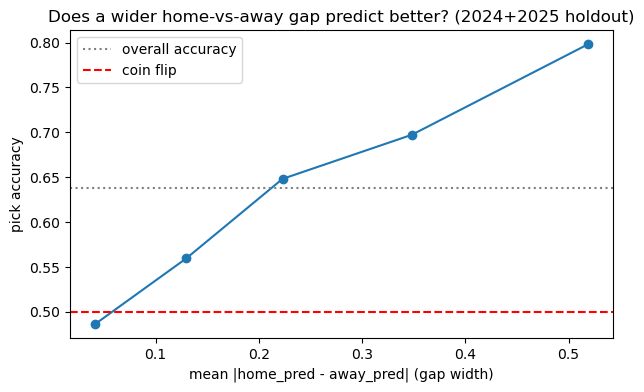

In [21]:
# Visualize the hypothesis: accuracy should rise as the home-vs-away gap widens
plt.figure(figsize=(7, 4))
plt.plot(gap_summary['mean_abs_gap'], gap_summary['accuracy'], marker='o')
plt.axhline(y=games['correct'].mean(), color='gray', linestyle=':', label='overall accuracy')
plt.axhline(y=0.5, color='r', linestyle='--', label='coin flip')
plt.xlabel('mean |home_pred - away_pred| (gap width)')
plt.ylabel('pick accuracy')
plt.title('Does a wider home-vs-away gap predict better? (2024+2025 holdout)')
plt.legend()
plt.show()